In [5]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(1)
np.random.seed(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [7]:
n = 360
t = np.arange(n)
trend = 0.03 * t
seasonal_daily = 1.5 * np.sin(2 * np.pi * t / 24)
seasonal_weekly = 0.8 * np.cos(2 * np.pi * t / (24 * 7))
noise = np.random.normal(0, 0.35, size=n)
series = 15 + trend + seasonal_daily + seasonal_weekly + noise
df = pd.DataFrame({'time': t, 'value': series})
df.head()

,time,value
0,0,16.368521
1,1,16.003554
2,2,16.422903
3,3,16.570091
4,4,17.512995


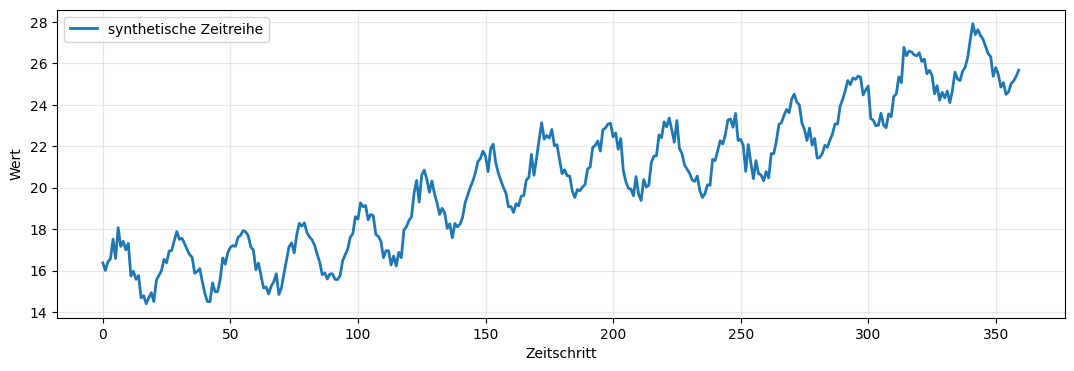

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['time'], df['value'], linewidth=2, label='synthetische Zeitreihe')
ax.set_xlabel('Zeitschritt')
ax.set_ylabel('Wert')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [9]:
def make_supervised(series: np.ndarray, lookback: int = 24, horizon: int = 1):
    X, y = [], []
    for end in range(lookback, len(series) - horizon + 1):
        start = end - lookback
        X.append(series[start:end])
        y.append(series[end + horizon - 1])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

lookback = 24 * 7
X, y = make_supervised(df['value'].to_numpy(), lookback=lookback, horizon=1)
X.shape, y.shape



((192, 168), (192,))